#  Model Evaluation Notebook

**Description**

This notebook is used for model performance evaluation by calculating these metrics including IoU and Dice coefficient (F1-score) and model prediction visualization on the whole area.

**Input file(s)**

TBD

**Output file(s)**

TBD

**Requirements/Dependencies**

TBD

# Import library

In [1]:
import os
import sys

# Add the root directory to Python path so that we can import the modules
root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(root_dir)

In [2]:
import torchgeo
import torch
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.loggers import CSVLogger
from matplotlib.ticker import MaxNLocator
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchgeo.datasets.utils import stack_samples
from lightning.pytorch import Trainer
from pugs_detection.modeling.segmentation_task import (
    CustomSegmentationTask
)
from pugs_detection.modeling.evaluation import (
    generate_confusion_matrix
)
from pugs_detection.plots import (
    visualize_area,
    visualize_from_torchgeo_dataloader,
    visualize_predictions
)
from pugs_detection.dataset import (
    PredictedImageDataset,
    create_dataset_split
)
from pugs_detection.utils import (
    set_all_seeds
)

In [3]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="You will likely lose important projection information when converting to a PROJ string from another format.*",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message="Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired.*",
    category=UserWarning,
)

# Set seed for reproducibility

In [4]:
set_all_seeds(42)

Seed set to 42


# Create Test dataloader

In [5]:
test_image_path = "../data/processed/tiles/test"
label_path = "../data/processed/ground truth/dresden_pugs_gt.geojson"
# band_list_predict = [0,1,2,3,4,5,6,7,8,9,10,11,12,13] # 13 is osm binary mask
# band_list_predict = [0,1,2,3,4,5,6,7,8,9,10,11,12] # 13 is osm binary mask
band_list_predict = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
batch_size = 16

In [6]:
test_dataset = create_dataset_split(
    test_image_path, label_path, 32633, band_list_predict, "test", None
)

Seed set to 42


Using all 36 patches for test set


In [7]:
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, collate_fn=stack_samples, num_workers=1
)

In [8]:
len(test_loader)

3

Seed set to 42


Sample 0:
  Image shape: (13, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.39


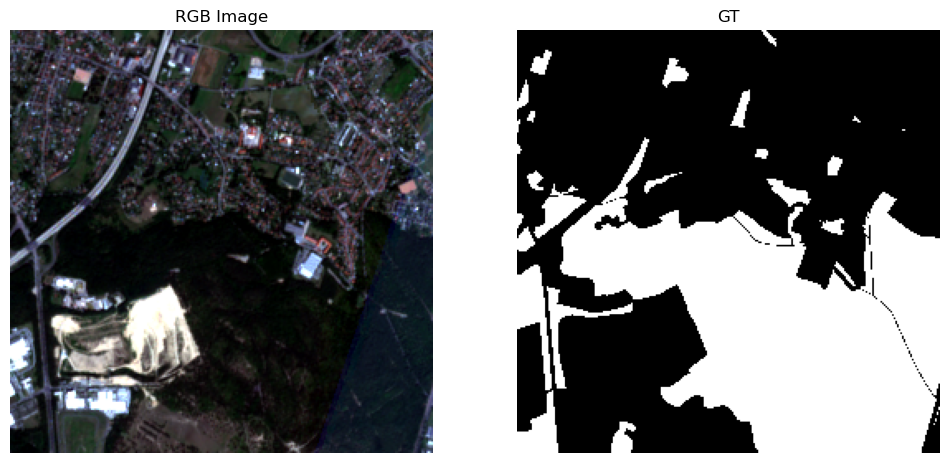

Sample 1:
  Image shape: (13, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.49


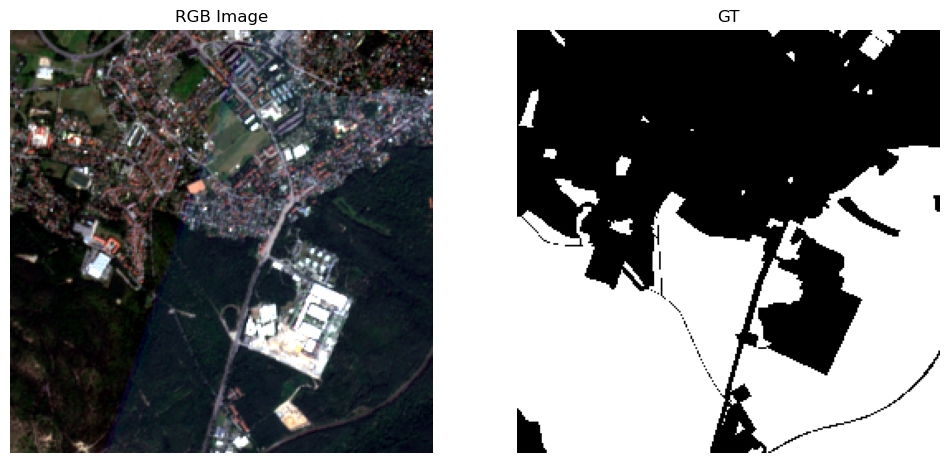

Sample 2:
  Image shape: (13, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.71


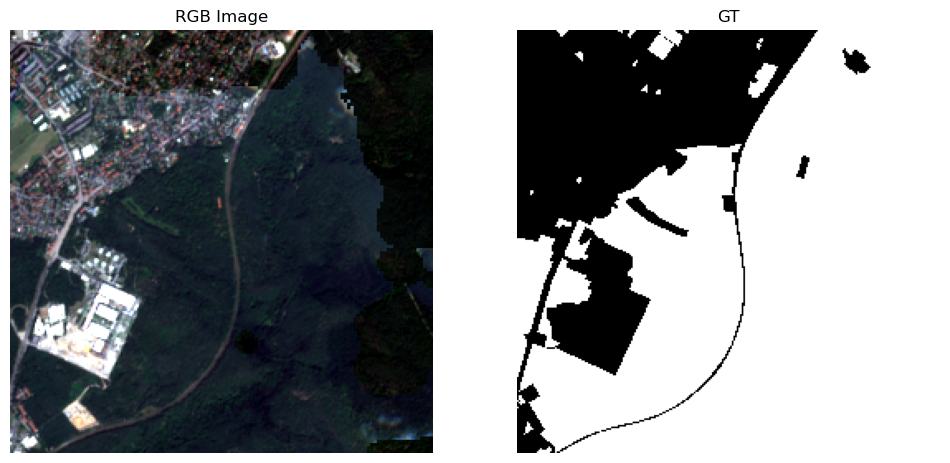

In [9]:
# visualize_from_torchgeo_dataloader(test_loader, 3, 'additional', [13])
visualize_from_torchgeo_dataloader(test_loader, 3, "original")

# Load model from checkpoint

In [10]:
# Path to your checkpoint file
checkpoint_path = "../notebooks/lightning_logs/pugs_detection/version_0/checkpoints/epoch=46-val_loss=0.22.ckpt"

# Direct loading with the correct channel count
model = CustomSegmentationTask.load_from_checkpoint(
    checkpoint_path,
    in_channels=13,  # Match what's in the checkpoint
)

# Evaluate the model

In [11]:
checkpoint_callback = ModelCheckpoint(
    filename="{epoch:02d}-{val_loss:.2f}",
    monitor="val_loss",
    save_top_k=2,  # Save chckpoint with the best validation loss
    # every_n_epochs=5  # Save checkpoint every n epochs
)

In [12]:
early_stopping = EarlyStopping(monitor="val_loss", patience=10)

In [13]:
logger = CSVLogger("lightning_logs", name="pugs_detection_test_result")

In [14]:
trainer = Trainer(
    max_epochs=50,
    deterministic=True,
    accelerator="cpu",
    log_every_n_steps=1,
    callbacks=[checkpoint_callback, early_stopping],
    logger=logger,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## Viz prediction

In [15]:
trainer.test(model=model, dataloaders=test_loader, ckpt_path=checkpoint_path)

Restoring states from the checkpoint path at ../notebooks/lightning_logs/pugs_detection/version_0/checkpoints/epoch=46-val_loss=0.22.ckpt
/root/miniforge3/envs/pugs-detection-new/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:362: The dirpath has changed from 'lightning_logs/pugs_detection/version_0/checkpoints' to 'lightning_logs/pugs_detection_test_result/version_0/checkpoints', therefore `best_model_score`, `kth_best_model_path`, `kth_value`, `last_model_path` and `best_k_models` won't be reloaded. Only `best_model_path` will be reloaded.
Loaded model weights from the checkpoint at ../notebooks/lightning_logs/pugs_detection/version_0/checkpoints/epoch=46-val_loss=0.22.ckpt
/root/miniforge3/envs/pugs-detection-new/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19

Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   test_BinaryAccuracy      0.9611718654632568
 test_BinaryJaccardIndex     0.770550549030304
        test_loss            0.364390105009079
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_BinaryAccuracy': 0.9611718654632568,
  'test_BinaryJaccardIndex': 0.770550549030304,
  'test_loss': 0.364390105009079}]

In [16]:
# Create output directory if needed
output_dir='../reports/visualization/v0'

Prediction shape: torch.Size([16, 1, 256, 256])
Mask shape: torch.Size([16, 256, 256])
Sample 0 - Image shape: (13, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 1 - Image shape: (13, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 2 - Image shape: (13, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 3 - Image shape: (13, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.7983424067497253


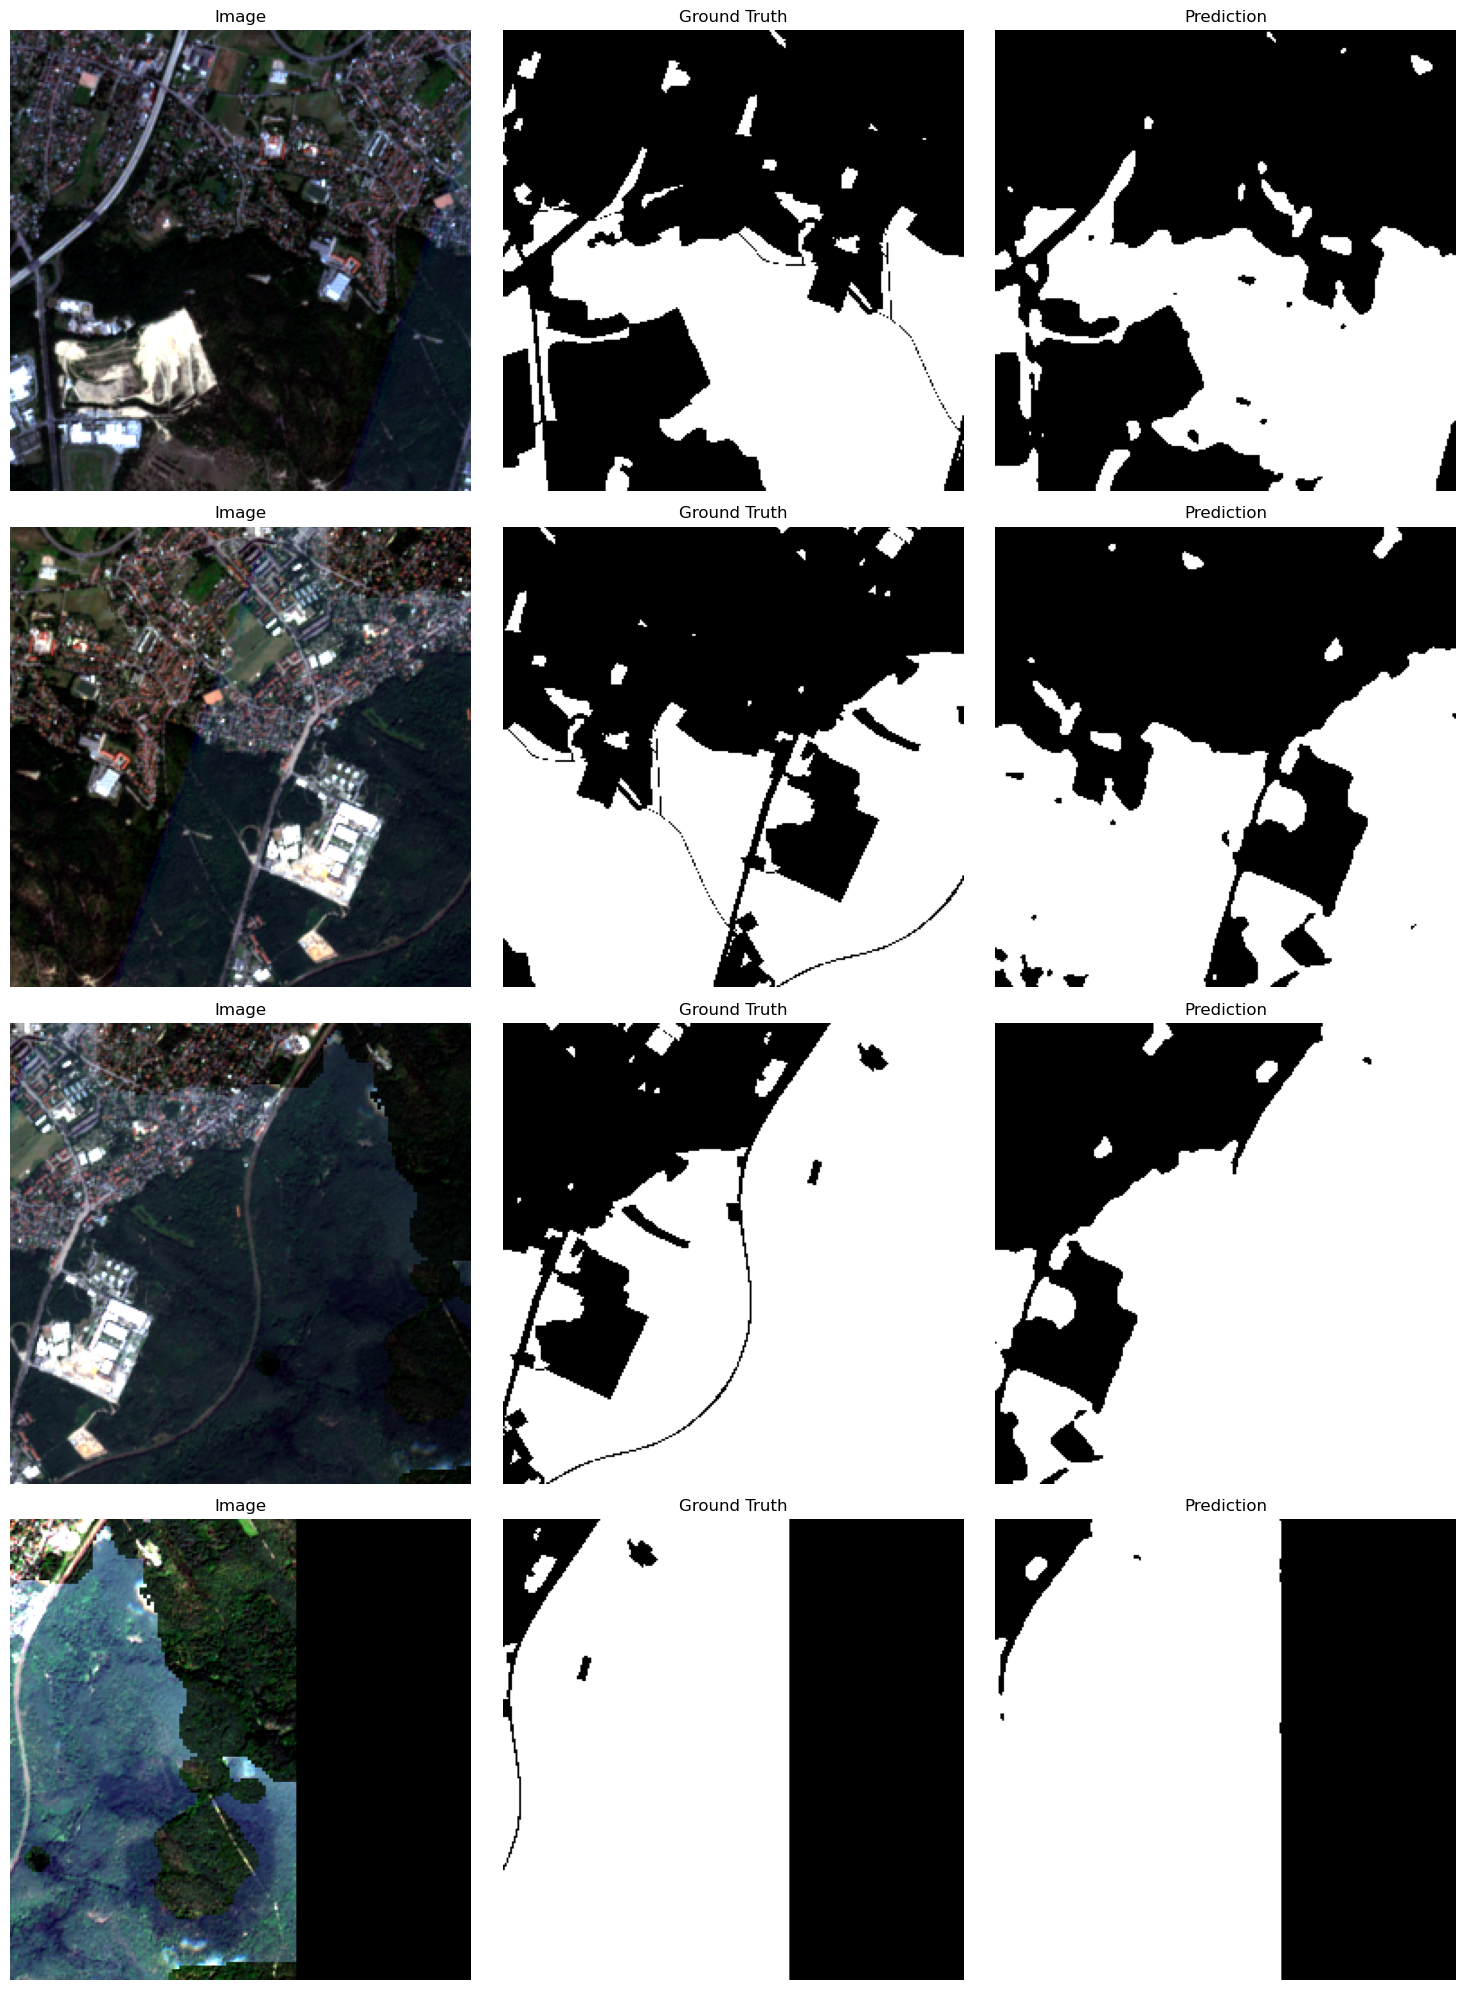

Prediction shape: torch.Size([16, 1, 256, 256])
Mask shape: torch.Size([16, 256, 256])
Sample 0 - Image shape: (13, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 1 - Image shape: (13, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 2 - Image shape: (13, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.9967949390411377
Sample 3 - Image shape: (13, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.9246196150779724


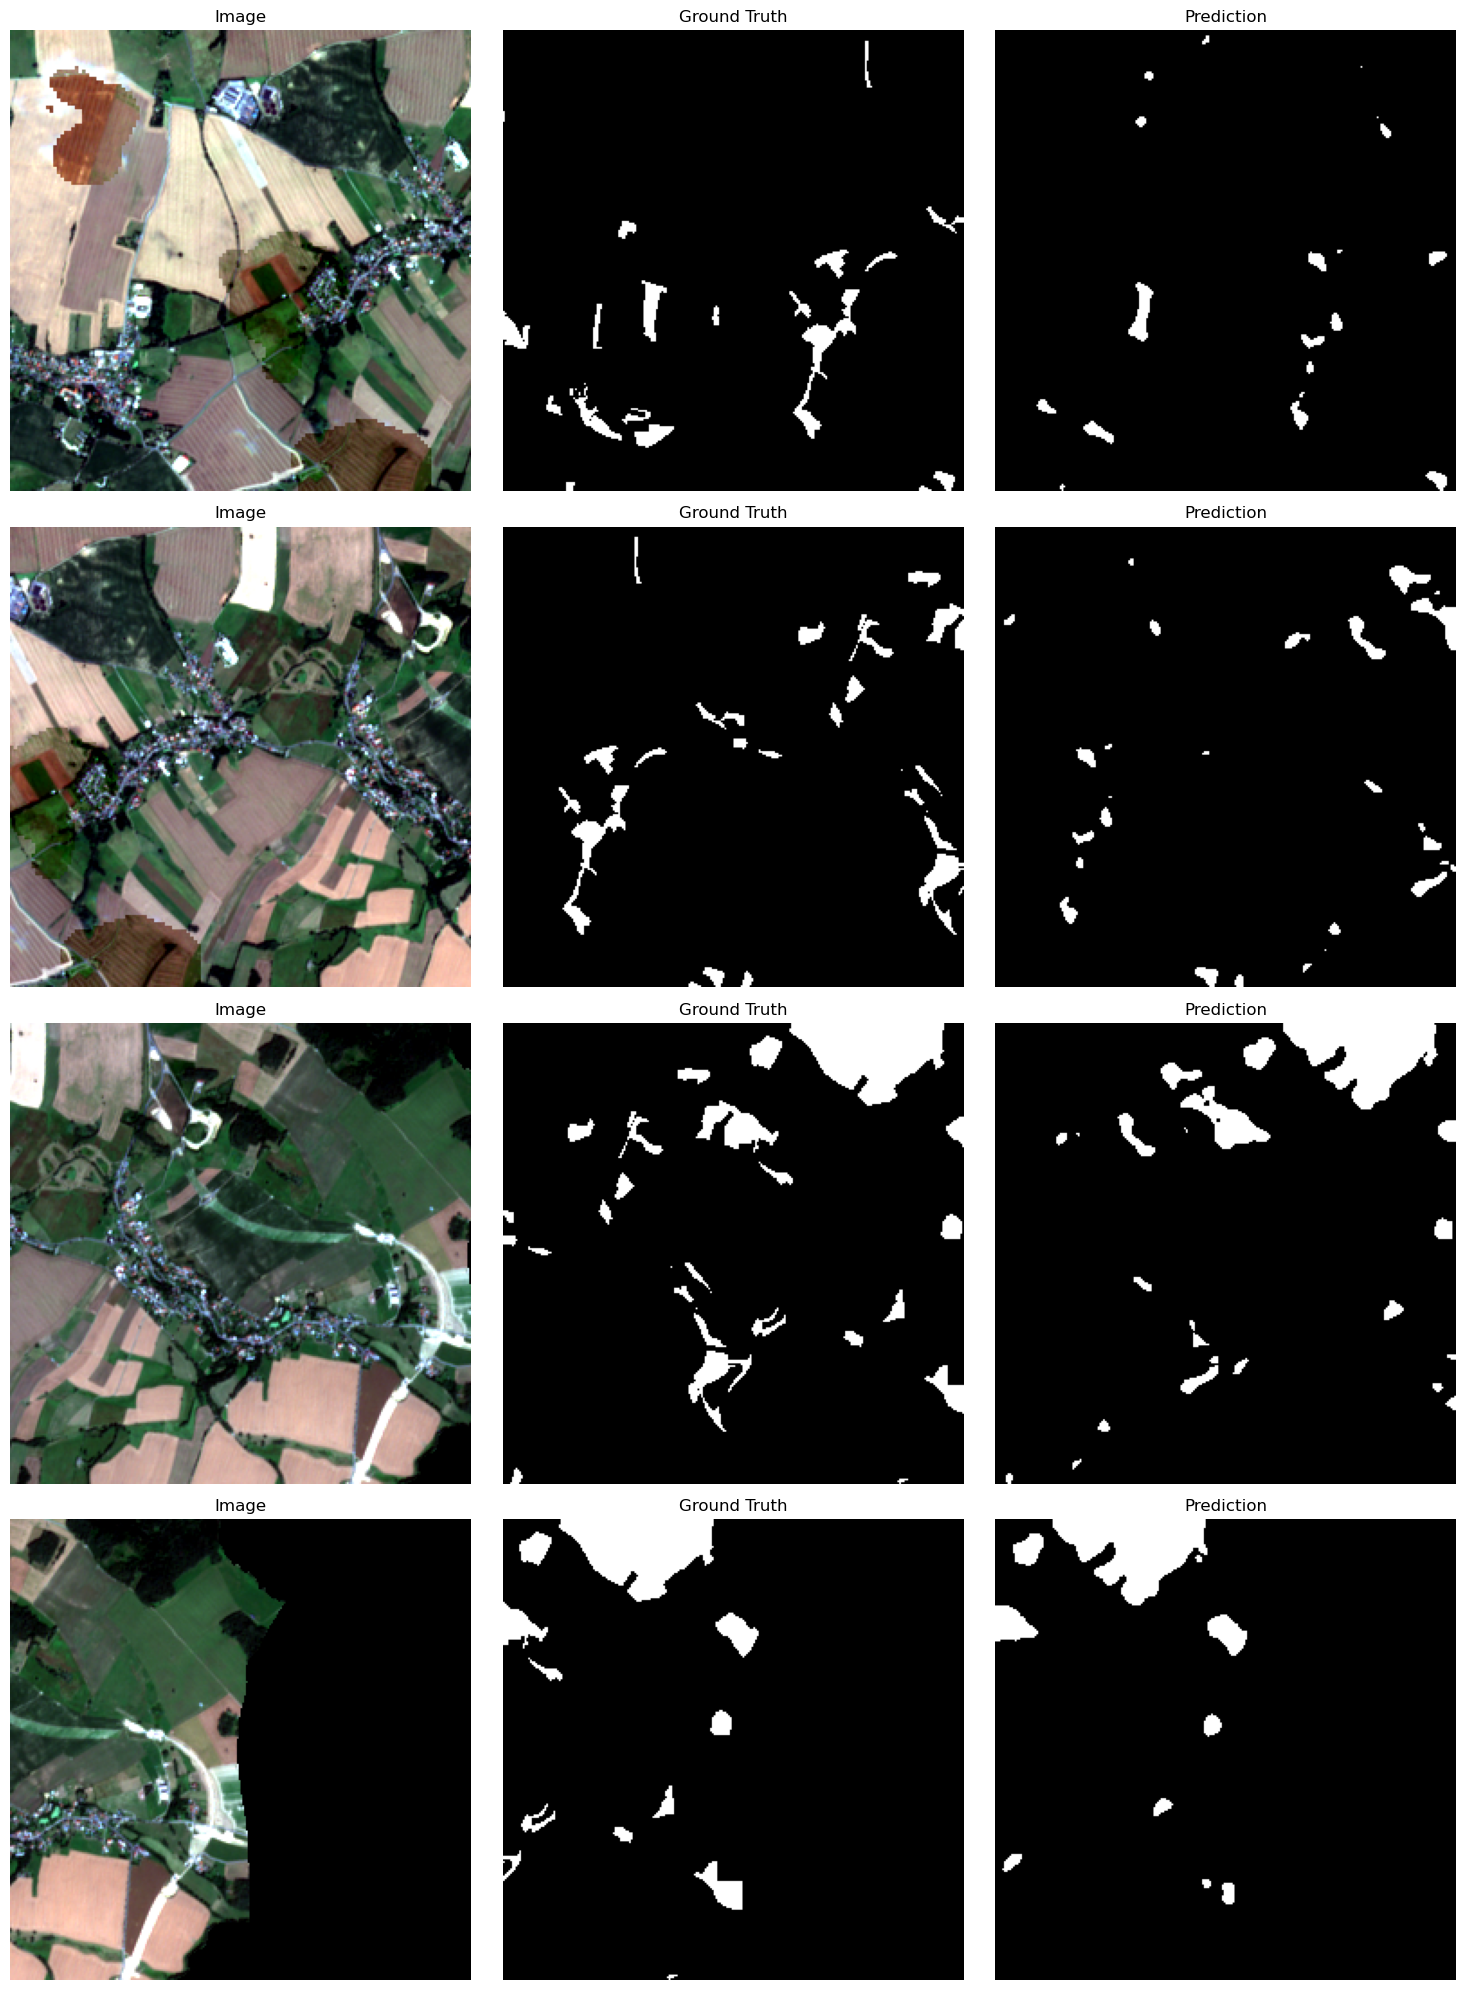

Prediction shape: torch.Size([4, 1, 256, 256])
Mask shape: torch.Size([4, 256, 256])
Sample 0 - Image shape: (13, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.8341105580329895
Sample 1 - Image shape: (13, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.881877064704895
Sample 2 - Image shape: (13, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.870665431022644
Sample 3 - Image shape: (13, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.7889150977134705


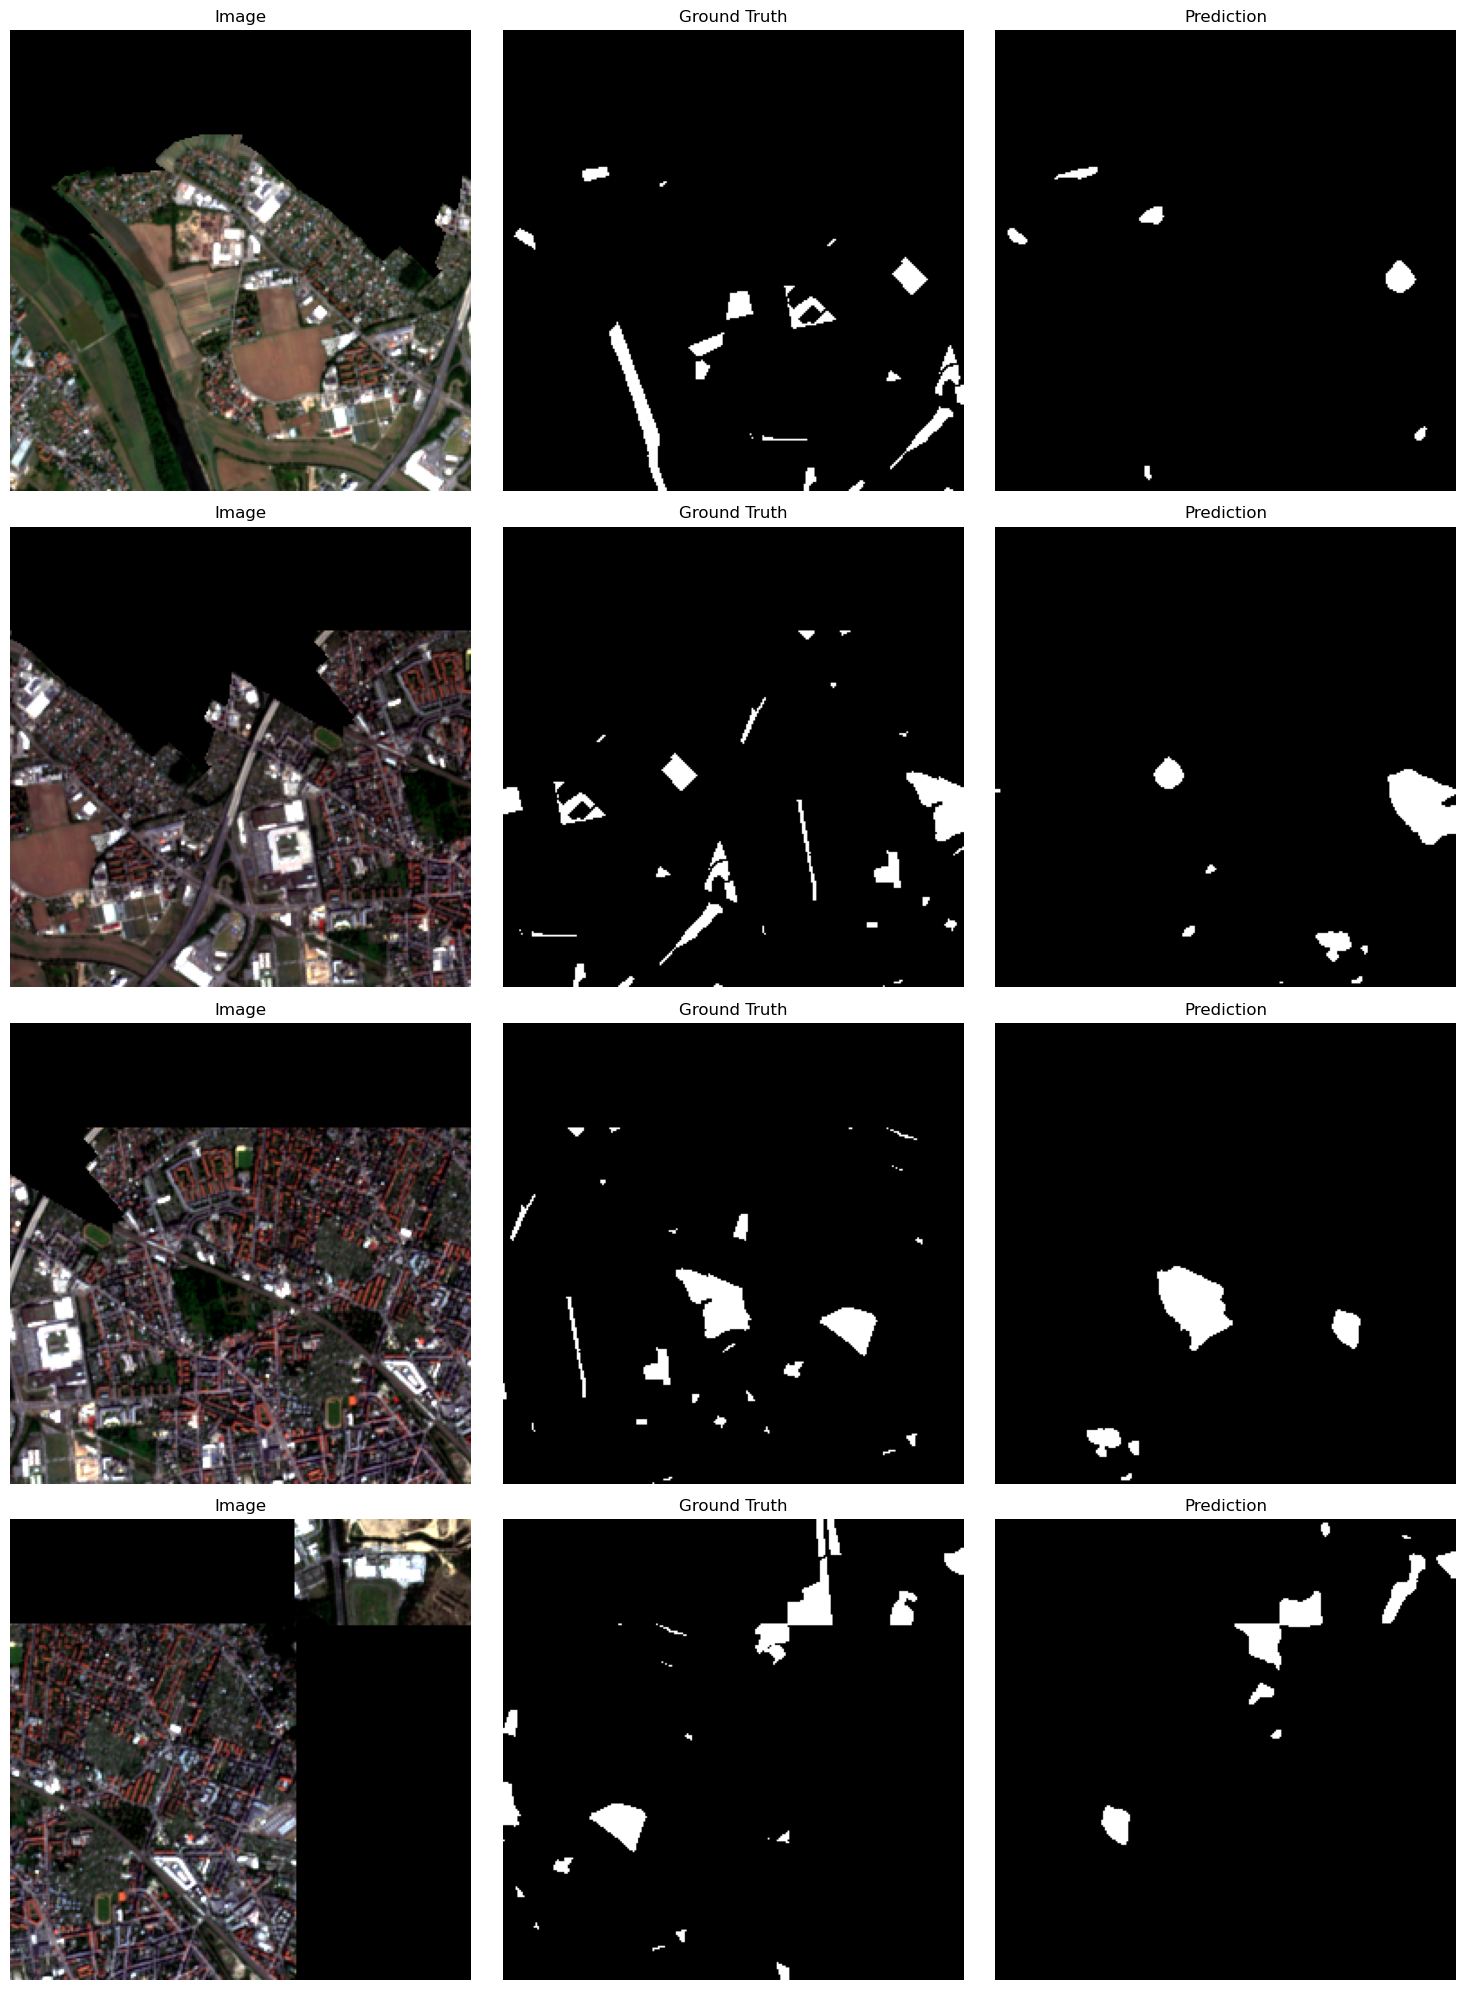

In [17]:
# visualize_predictions_test(task, test_loader, mode='additional', replace_band_pos=[13])
visualize_predictions(model, test_loader, mode="original", output_dir=output_dir)

## Confusion matrix

In [18]:
cm = generate_confusion_matrix(model, test_loader)
print("True Negative:", cm[0, 0])
print("False Positive:", cm[0, 1])
print("False Negative:", cm[1, 0])
print("True Positive:", cm[1, 1])

True Negative: 1960049
False Positive: 35129
False Negative: 56478
True Positive: 307640


In [19]:
precision = cm[1, 1] / (cm[1, 1] + cm[0, 1])
recall = cm[1, 1] / (cm[1, 1] + cm[1, 0])
f1 = 2 * precision * recall / (precision + recall)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Accuracy: {np.sum(np.diag(cm)) / np.sum(cm):.4f}")
print(f"IoU: {cm[1, 1] / (cm[1, 1] + cm[0, 1] + cm[1, 0]):.4f}")

Precision: 0.8975
Recall: 0.8449
F1 Score: 0.8704
Accuracy: 0.9612
IoU: 0.7706


# Plot train loss and val loss

In [22]:
metrics_path = "../notebooks/lightning_logs/pugs_detection/version_0/metrics.csv"
loss_graph_path = "../reports/figures/loss graph/loss_grpah_v0.png"

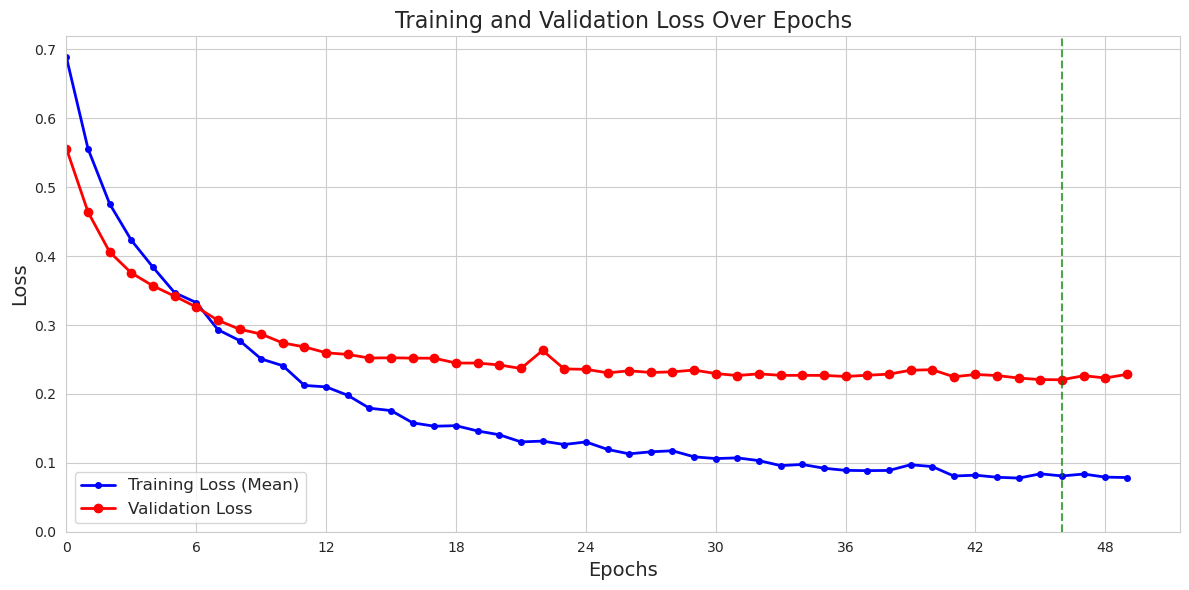

Best model at epoch 46:
  Val Loss: 0.2206
  Val Jaccard: 0.8401


<Figure size 640x480 with 0 Axes>

In [23]:
# Read the metrics CSV file
df = pd.read_csv(metrics_path)

# Create a figure with appropriate size
fig = plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Plot mean training loss per epoch
train_df = df.groupby("epoch")["train_loss"].mean().reset_index()
plt.plot(
    train_df["epoch"],
    train_df["train_loss"],
    "b-",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Training Loss (Mean)",
)

# Plot validation loss - filter rows where val_loss exists
val_df = df[df["val_loss"].notna()].copy()
plt.plot(
    val_df["epoch"],
    val_df["val_loss"],
    "r-",
    marker="o",
    markersize=6,
    linewidth=2,
    label="Validation Loss",
)

# Add labels and title
plt.xlabel("Epochs", fontsize=14)
plt.ylabel("Loss", fontsize=14)
plt.title("Training and Validation Loss Over Epochs", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)

# Adjust axis for better visualization
plt.xlim(left=0)
plt.ylim(bottom=0)

# Set x-axis to integer ticks only
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# Add vertical line at best validation performance
best_epoch = val_df.loc[val_df["val_loss"].idxmin()]["epoch"]
plt.axvline(
    x=best_epoch,
    color="g",
    linestyle="--",
    alpha=0.7,
    label=f"Best model (epoch {int(best_epoch)})",
)

plt.tight_layout()
plt.show()

# Save figure
plt.savefig(loss_graph_path, dpi=300, bbox_inches='tight')
plt.close(fig)

# Print best epoch stats
best_row = val_df[val_df["epoch"] == best_epoch].iloc[0]
print(f"Best model at epoch {int(best_epoch)}:")
print(f"  Val Loss: {best_row['val_loss']:.4f}")
print(f"  Val Jaccard: {best_row['val_BinaryJaccardIndex']:.4f}")

# Predict whole area

In [24]:
image_path_whole_area = "../data/processed/sentinel-2/stacked_sentinel2_dresden.geotiff"

In [25]:
prediction_image_path = '../reports/prediction_results_track/whole_area_prediction/prediction_sat_v0.tif'

In [26]:
# Use custom collate function to maintain window_ifo as list of tuples
# so we can easily extract the window coordinates
def custom_collate_fn(batch):
    """Keep window coordinates as a list of tuples instead of tensors"""
    images = torch.stack([torch.from_numpy(item["image"]) for item in batch])
    window_infos = [item["window_info"] for item in batch]

    return {"image": images, "window_info": window_infos}

In [27]:
# Regular DataLoader without custom collate function
inference_dataset = PredictedImageDataset(image_path_whole_area, patch_size=256, stride=256, band_list_predict=band_list_predict)
# Regular DataLoader WITH custom collate function
inference_loader = DataLoader(
    inference_dataset,
    batch_size=4,
    num_workers=4,
    collate_fn=custom_collate_fn,  # Use our custom collate
)
# Create output array
prediction_map = np.zeros(
    (inference_dataset.height, inference_dataset.width), dtype=np.float32
)
counts = np.zeros((inference_dataset.height, inference_dataset.width), dtype=np.float32)

# Process all patches
model.eval()
with torch.no_grad():
    for batch in tqdm(inference_loader):
        # Get images and window info
        images = batch["image"]
        windows = batch["window_info"]

        # Run inference
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        # Process each patch in the batch
        # Process each patch in the batch
        for i, window in enumerate(windows):
            # Get window coordinates
            x_off = window.col_off
            y_off = window.row_off
            width = window.width
            height = window.height

            # Get prediction for this patch
            pred = preds[i].squeeze().cpu().numpy()
            # Ensure prediction is 2D for plotting
            if pred.ndim > 2:
                if pred.shape[0] == 1:
                    # Single channel but in shape (1, H, W)
                    pred = pred.squeeze(0)
                else:
                    pred = pred[1]
            # Add to output array
            prediction_map[y_off : y_off + height, x_off : x_off + width] += pred
            counts[y_off : y_off + height, x_off : x_off + width] += 1

# Average overlapping predictions
with np.errstate(divide="ignore", invalid="ignore"):
    prediction_map = np.divide(prediction_map, counts)
    # prediction_map = np.nan_to_num(prediction_map)
    # Add thresholding to force binary output
    prediction_map = (prediction_map > 0.5).astype(np.uint8)

# Save the prediction
with rasterio.open(
    prediction_image_path,
    "w",
    driver="GTiff",
    height=inference_dataset.height,
    width=inference_dataset.width,
    count=1,
    dtype=rasterio.float32,
    crs=inference_dataset.crs,
    transform=inference_dataset.transform,
) as dst:
    dst.write(prediction_map[np.newaxis, :, :])

100%|██████████| 25/25 [00:07<00:00,  3.21it/s]


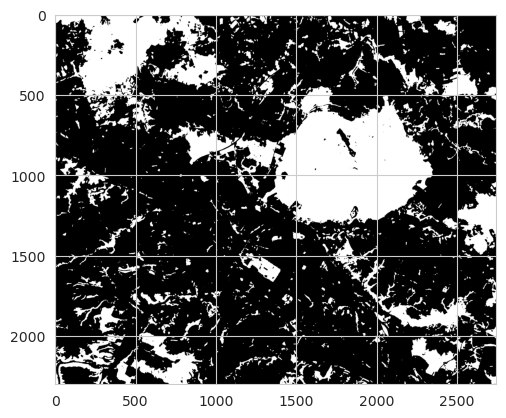

In [28]:
open_image = rasterio.open(prediction_image_path)
image = open_image.read(1)
plt.imshow(image, cmap="gray")
open_image.close()

# Save the visualization of prediction and ground truth

In [29]:
viz_coords = [
    (256, 640), (512, 896), (512, 1152), (1920, 2000), (640,0), 
    (768, 1152), (896, 1024), (896, 1152), (896, 1280), (1024, 1024), 
    (1024, 1280), (1024, 1536), (1152, 1408), (1408, 1280), (1536, 1536)
]

In [30]:
for x, y in tqdm(viz_coords, desc="Generating visualizations", unit="image"):
    try:
        fig = visualize_area(
            original_image_path=image_path_whole_area,
            prediction_path=prediction_image_path,
            ground_truth_path='../data/processed/ground truth/dresden_pugs_gt.geotiff',
            x_coord=x,
            y_coord=y,
            window_size=256
        )
        
        if output_dir:
            # Save to file
            fig_path = os.path.join(output_dir, f"region_{x}_{y}.png")
            fig.savefig(fig_path, bbox_inches='tight', dpi=300)
            plt.close(fig)        
    except Exception as e:
        print(f"Error visualizing window at ({x},{y}): {e}")

print()
print("Complete saving the files")

Generating visualizations:   0%|          | 0/15 [00:00<?, ?image/s]

Generating visualizations: 100%|██████████| 15/15 [00:07<00:00,  2.14image/s]


Complete saving the files


In [ ]:
# Usage example with output directory
# visualize_whole_image(
#     original_image_path=image_path,
#     prediction_path=file_output_path,
#     ground_truth_path='../data/processed/ground truth/dresden_pugs_gt.geotiff',
#     window_size=256,
#     stride=128,  # Larger stride to sample fewer areas
#     output_dir='../reports/visualization/region_samples'
# )